In [1]:
from pathlib import Path

import automech
import cantera
import polars as pl
from automech.species import Species
from cantera.ck2yaml import Parser
from project_utilities import p_, util, workflow

tag = "Z_mess_v7"
file = util.notebook_file() if util.is_notebook() else __file__
root_path = Path("..")
chemkin_path = p_.chemkin(root_path)

In [2]:
tag0 = "Z_mess_v4"

# 2. Read in AVC species set with thermochemistry
mech_file0 = p_.calculated_mechanism(tag0, "json", p_.data(root_path))
mech0 = automech.io.read(mech_file0)
spc_df0 = mech0.species

In [3]:
def select_cho_species(spc_df: pl.DataFrame) -> pl.DataFrame:
    all_symbols = {f.name for f in spc_df.schema["formula"].fields}  # ty:ignore[unresolved-attribute]
    included_symbols = {"C", "H", "O"}
    excluded_symbols = all_symbols - included_symbols

    return spc_df.filter(
        pl.all_horizontal(
            [
                pl.col(Species.formula).struct.field(s).fill_null(0) == 0
                for s in excluded_symbols
            ]
        )
    )


def racemize(spc_df: pl.DataFrame) -> pl.DataFrame:
    return spc_df.with_columns(pl.col(Species.name).str.replace(r"[01]$", "R")).unique(
        subset=Species.name
    )

In [4]:
failed_species = [
    "C5H7(1315)",
    "S(1402)rR",
    "S(1336)rR",
    "S(1641)ze",
    "S(1633)",
    "S(1629)",
    "S(1641)ez",
    "S(1406)rR",
    "S(1250)e",
    "C5H8O(837)z",
    "S(1562)rsR",
    "S(1445)z",
    "S(1421)ze",
    "S(1511)e",
    "S(1492)rsR",
    "S(1583)z",
    "S(1344)z",
    "S(163)zz",
    "S(1411)rR",
    "S(1485)e",
    "S(1335)rR",
    "S(1477)",
    "S(1615)",
    "C5H9O(856)",
    "S(1344)e",
    "S(1644)rsR",
    "S(1641)ee",
    "S(1445)e",
    "S(1673)zz",
    "S(1635)rR",
    "S(1492)rrR",
    "S(1673)ez",
    "S(1370)",
    "S(1388)",
    "S(1588)z",
    "S(1348)rR",
    "S(1502)eeee",
    "S(1613)z",
    "C4H7(1434)",
    "S(1373)rsR",
    "S(1579)rR",
    "S(1644)rrR",
    "S(1588)e",
    "S(1453)eee",
    "S(1613)e",
    "S(1599)",
    "S(1583)e",
    "S(1624)",
    "S(1374)rR",
    "S(1640)zz",
    "S(1641)zz",
    "S(1250)z",
    "S(1532)erR",
    "S(1504)rsR",
    "S(1385)z",
    "S(1562)rrR",
    "S(1500)rsR",
    "S(1569)",
]


def drop_failed_species(spc_df: pl.DataFrame, visualize: bool = False) -> pl.DataFrame:
    if visualize:
        print(f"{len(failed_species)} failed species:")
        automech.species.display(spc_df, spc_vals_=failed_species, stereo=False)
    return spc_df.filter(~pl.col(Species.name).is_in(failed_species))

58 failed species:
name: S(1421)ze
smiles: C=/C/C(=/C([CH2])\O)O


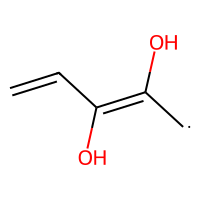

name: S(1579)rR
smiles: CC[C@@H]1C=C1[O]


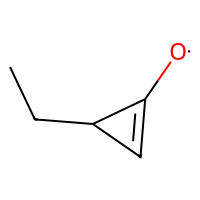

name: S(1673)ez
smiles: [H]/[C]=C/C=C\OC


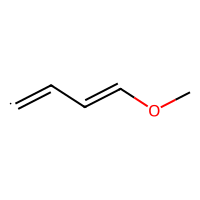

name: S(1485)e
smiles: C=C/C(=C\C)[O]


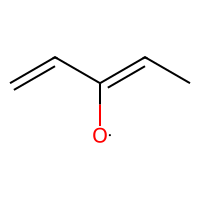

name: S(1613)z
smiles: C=C/C=C(CO)\O


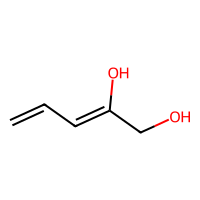

name: S(1500)rsR
smiles: C[C@H]1[C@@H]2C[C]2OO1


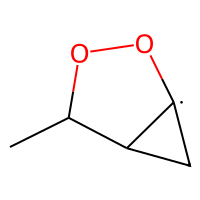

name: S(1562)rsR
smiles: C[C@H]1C[C@H]1[C]=O


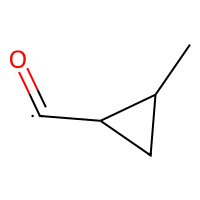

name: C5H7(1315)
smiles: [CH2]C12CC1C2


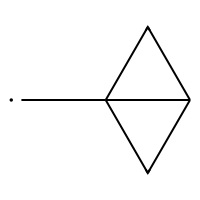

name: S(1633)
smiles: [CH2]C1CC(C1)O


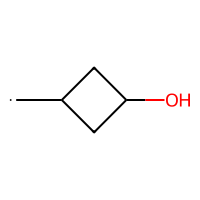

name: S(1641)ee
smiles: O/C=C/C=C/CO


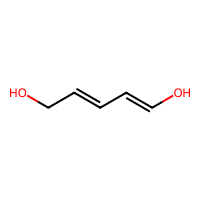

name: S(1588)z
smiles: CC/C=C(C)\O[O]


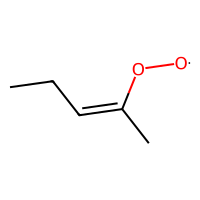

name: S(1388)
smiles: C=CCCC(=O)[O]


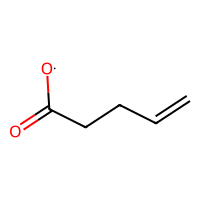

name: S(1641)ze
smiles: O/C=C/C=C\CO


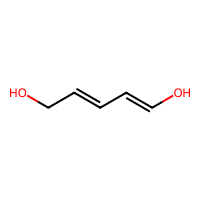

name: S(1370)
smiles: C1[C]2CC1COO2


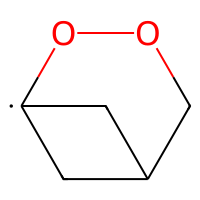

name: S(1344)e
smiles: [CH2]/C=C/OOC=C


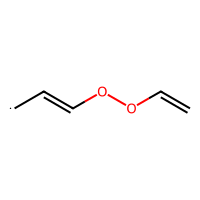

name: S(1562)rrR
smiles: C[C@H]1C[C@@H]1[C]=O


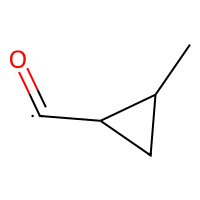

name: S(1406)rR
smiles: [O]C1=CC[C@@H](C1)O


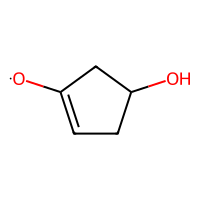

name: S(1250)z
smiles: O=[C]CC/C=C\O


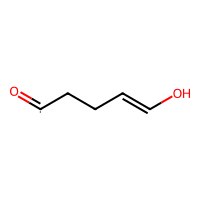

name: S(1615)
smiles: [O]C1=CC1


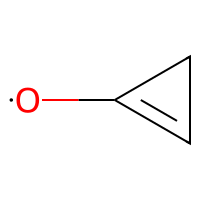

name: S(1373)rsR
smiles: C[C@@]12C[C@@H]1[CH]OO2


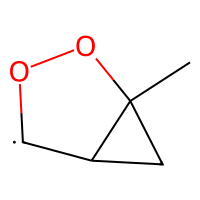

name: S(1641)zz
smiles: O/C=C\C=C/CO


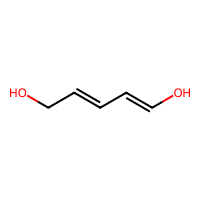

name: S(1453)eee
smiles: C/C=/C(\C=\C\[O])O


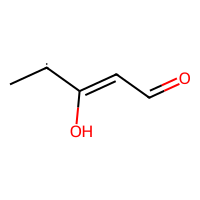

name: S(1640)zz
smiles: C/C=C\C(=C\O)O


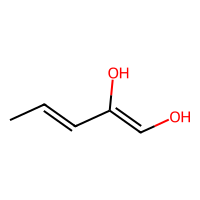

name: S(1374)rR
smiles: C1C[C@H]2COO[C]21


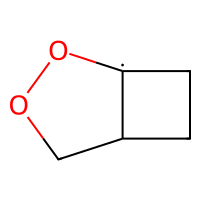

name: S(1402)rR
smiles: [CH2]C[C@H](C=C=O)O


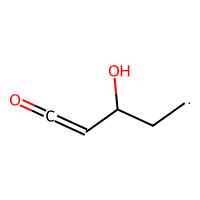

name: S(1569)
smiles: C=C(CC[C]=O)O


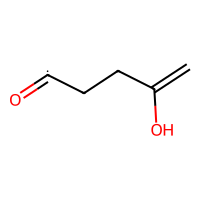

name: S(1588)e
smiles: CC/C=C(C)/O[O]


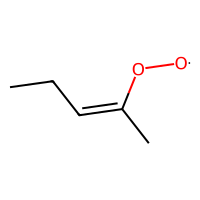

name: S(1335)rR
smiles: [CH2][C@H]1CC=COO1


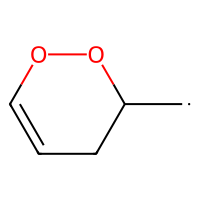

name: S(1613)e
smiles: C=C/C=C(CO)/O


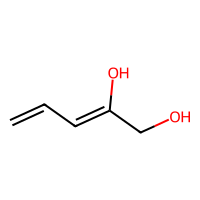

name: S(1445)z
smiles: [O]C1(/C=C\O)CC1


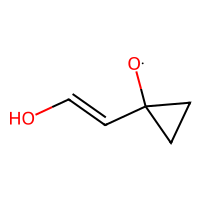

name: C4H7(1434)
smiles: [CH]1CCC1


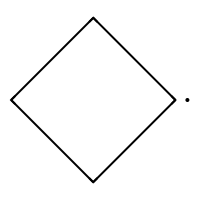

name: S(1445)e
smiles: [O]C1(/C=C/O)CC1


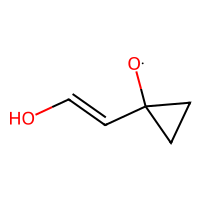

name: S(1532)erR
smiles: C[C@@H]([C]=O)/C=C/O


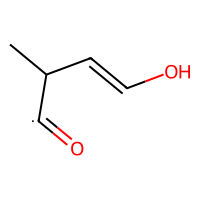

name: S(1583)e
smiles: C/C=C(C[C]=O)/O


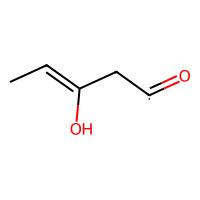

name: S(1635)rR
smiles: CC[C@H]1[C](C)OO1


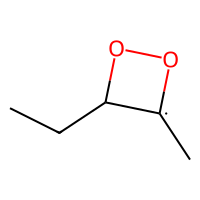

name: S(1641)ez
smiles: O/C=C\C=C\CO


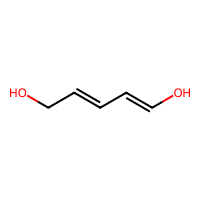

name: S(1583)z
smiles: C/C=C(C[C]=O)\O


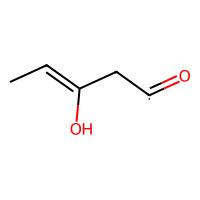

name: S(1644)rrR
smiles: C[C@@]1(C[C@@H]1C=O)[O]


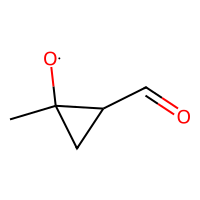

name: S(1644)rsR
smiles: C[C@]1(C[C@@H]1C=O)[O]


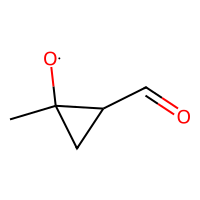

name: S(1629)
smiles: O=[C]C1CCC1


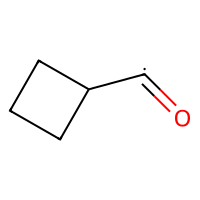

name: C5H9O(856)
smiles: CCCC[C]=O


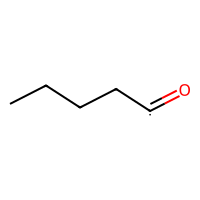

name: S(1336)rR
smiles: C1C[C@H]2C[C]1OO2


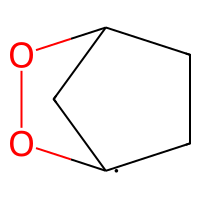

name: S(1504)rsR
smiles: O=[C][C@H]1CC[C@H]1O


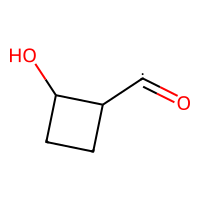

name: S(163)zz
smiles: [O]/C=/C\C=\O


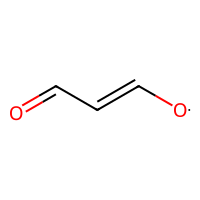

name: C5H8O(837)z
smiles: C/C=C\CC=O


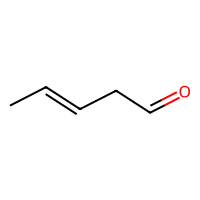

name: S(1502)eeee
smiles: O/[CH]/C=/C/C=/C/O


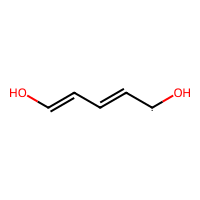

name: S(1511)e
smiles: C/C=C/C[C]=O


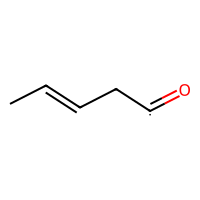

name: S(1411)rR
smiles: C=C1[C@@H]([O])O1


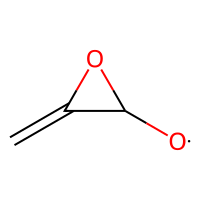

name: S(1492)rsR
smiles: C=C[C@]1(C[C@@H]1O)[O]


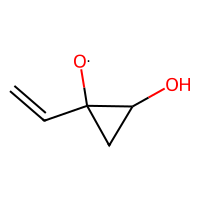

name: S(1477)
smiles: O=[C]CC1CC1


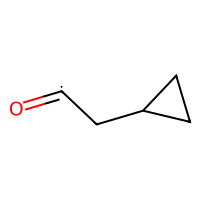

name: S(1599)
smiles: CC1=CC=CO1


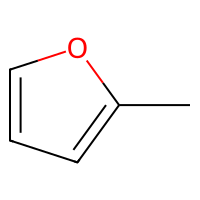

name: S(1344)z
smiles: [CH2]/C=C\OOC=C


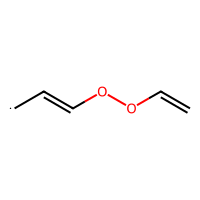

name: S(1492)rrR
smiles: C=C[C@@]1(C[C@@H]1O)[O]


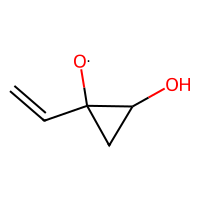

name: S(1348)rR
smiles: C=C[C@@H](C[C]=O)O


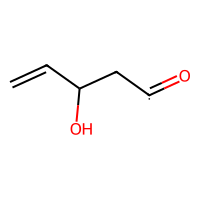

name: S(1385)z
smiles: C=CO/C(=C\C)[O]


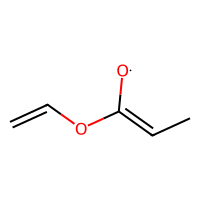

name: S(1250)e
smiles: O=[C]CC/C=C/O


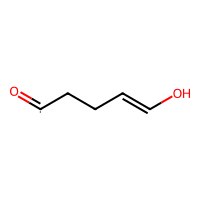

name: S(1673)zz
smiles: [H]/[C]=C\C=C/OC


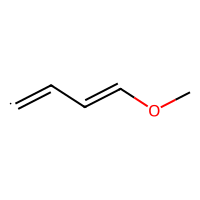

name: S(1624)
smiles: CC[CH]C1(C)OO1


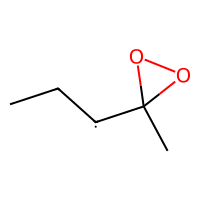

In [5]:
tag1 = "cyclopentene_species_expanded"

# 1a. Read in ASC species set
spc_file1 = p_.data(root_path) / f"{tag1}.json"
spc_df1 = pl.read_json(spc_file1)
spc_df1 = select_cho_species(spc_df1)
spc_df1 = racemize(spc_df1)
spc_df1 = drop_failed_species(spc_df1, visualize=True)

spc_df1.filter(pl.col(Species.name).str.contains("1336"))

# 1b. Read in ASC thermochemistry
therm_file1 = p_.chemkin(root_path) / f"{tag1}.dat"
spc_df1 = automech.io.chemkin.read.thermo(
    therm_file1, spc_df=spc_df1, racemize=True, complete=True
)
assert spc_df1 is not None

# 1c. Remove species that were already included
spc_df1 = spc_df1.join(spc_df0, on=Species.name, how="anti")

In [6]:
# 3. Combine species sets and create new submechanism
mech = mech0.model_copy()
mech.species = pl.concat([spc_df0, spc_df1], how="vertical_relaxed")

calc_mech_json = p_.calculated_mechanism(tag, "json", p_.data(root_path))
print(f" - Calculated: {calc_mech_json}")
automech.io.write(mech, calc_mech_json)

calc_mech_ckin = p_.calculated_mechanism(tag, "dat", p_.chemkin(root_path))
print(f" - Calculated: {calc_mech_ckin}")
automech.io.chemkin.write.mechanism(mech, out=calc_mech_ckin)

calc_mech_yaml = p_.calculated_mechanism(tag, "yaml", path=p_.cantera(root_path))
print(f" - Calculated: {calc_mech_yaml}")

print("Converting ChemKin mechanism to Cantera YAML...")
Parser.convert_mech(calc_mech_ckin, out_name=calc_mech_yaml)

print("Validating Cantera model...")
cantera.Solution(calc_mech_yaml)

 - Calculated: ../data/Z_mess_v7_calc.json
 - Calculated: ../data/chemkin/Z_mess_v7_calc.dat
 - Calculated: ../data/cantera/Z_mess_v7_calc.yaml
Converting ChemKin mechanism to Cantera YAML...
Wrote YAML mechanism file to '../data/cantera/Z_mess_v7_calc.yaml'.
Mechanism contains 952 species and 140 reactions.
Validating Cantera model...


In [7]:
# 4. Prepare combined mechanism for simulation
workflow.prepare_simulation(tag, root_path)

Reading parent mechanism...
 - Parent: ../data/full_parent.json
Adding comments...
Expanding and updating parent...


  0%|          | 0/8489 [00:00<?, ?it/s]

Writing mechanism to JSON...
 - Full control: ../data/full_Z_mess_v7_control.json
 - Full calculated: ../data/full_Z_mess_v7_calc.json
 - Calculated: ../data/Z_mess_v7_calc.json
Writing mechanism to Chemkin...
 - Full control: ../data/chemkin/full_Z_mess_v7_control.dat
 - Full calculated: ../data/chemkin/full_Z_mess_v7_calc.dat
 - Calculated: ../data/chemkin/Z_mess_v7_calc.dat
Converting ChemKin mechanism to Cantera YAML...
Wrote YAML mechanism file to '../data/cantera/full_Z_mess_v7_control.yaml'.
Mechanism contains 2828 species and 14385 reactions.
Wrote YAML mechanism file to '../data/cantera/full_Z_mess_v7_calc.yaml'.
Mechanism contains 2832 species and 14455 reactions.
Validating Cantera model...


In [8]:
# 5. Prepare thermo-only mechanism for simulation
workflow.prepare_simulation(tag, root_path, thermo_only=True)

Removing calculated rates for thermo-only update...
Updating tag for thermo-only update...
Reading parent mechanism...
 - Parent: ../data/full_parent.json
Adding comments...
Expanding and updating parent...


  0%|          | 0/8489 [00:00<?, ?it/s]

Writing mechanism to JSON...
 - Full control: ../data/full_Z_mess_v7_thermo_only_control.json
 - Full calculated: ../data/full_Z_mess_v7_thermo_only_calc.json
 - Calculated: ../data/Z_mess_v7_thermo_only_calc.json
Writing mechanism to Chemkin...
 - Full control: ../data/chemkin/full_Z_mess_v7_thermo_only_control.dat
 - Full calculated: ../data/chemkin/full_Z_mess_v7_thermo_only_calc.dat
 - Calculated: ../data/chemkin/Z_mess_v7_thermo_only_calc.dat
Converting ChemKin mechanism to Cantera YAML...
Wrote YAML mechanism file to '../data/cantera/full_Z_mess_v7_thermo_only_control.yaml'.
Mechanism contains 2828 species and 14385 reactions.
Wrote YAML mechanism file to '../data/cantera/full_Z_mess_v7_thermo_only_calc.yaml'.
Mechanism contains 2832 species and 14385 reactions.
Validating Cantera model...


In [9]:
workflow.prepare_simulation_species(tag, root_path=root_path)


Reading in species...

Writing simulation species names to CSV...
../data/cantera/Z_mess_v7_species.csv


orig_name,Experiment,Lokachari,Hill,concentration,name
str,str,str,str,str,str
"""C5H8(522)""","""cyclopentene""","""CYC5H8""","""C5H8(522)""",null,"""C5H8(522)"""
"""C5H8O(825)""","""1,2-epoxycyclopentane""","""CPTYO12""","""C5H8O(825)""",null,"""C5H8O(825)rs"""
"""CPT(563)""","""cyclopentane""","""CPT""","""CPT(563)""","""CPT_frac""","""CPT(563)"""
"""O2(6)""","""O2""","""O2""","""O2(6)""","""O2_frac""","""O2(6)"""
"""N2""",null,"""N2""","""N2""","""N2_frac""","""N2"""
…,…,…,…,…,…
"""C4H8(253)""","""1-butene""","""C4H8-1""","""C4H8(253)""",null,"""C4H8(253)"""
"""C5H6(478)""","""cyclopentadiene""","""C5H6""","""C5H6(478)""",null,"""C5H6(478)"""
"""C6H6(970)""","""benzene""","""C6H6""","""C6H6(970)""",null,"""C6H6(970)"""
